Reference:
Roman, I. (n.d.). Music Information Retrieval. Retrieved April 22, 2025, from https://github.com/iranroman/musicinformationretrieval.com

# Zero Crossing Rate (ZCR)

- used to identify types of sounds in an audio signal (e.g. in speech recognition, music genre classification, and emotion detection)
- measures how often a signal changes sign/crosses the horizontal axis
- high ZCR → Noisy or high-frequency signals
- low ZCR → low-frequency signals

In [1]:
%matplotlib inline
import numpy, scipy, matplotlib.pyplot as plt, IPython.display as ipd
import librosa, librosa.display
plt.rcParams['figure.figsize'] = (15, 5)

### Step 1: Load a signal & listen to it

In [2]:
x, sr = librosa.load('audio/simple_loop.wav')

In [3]:
ipd.Audio(x, rate=sr)

### Step 2: Plot the signal

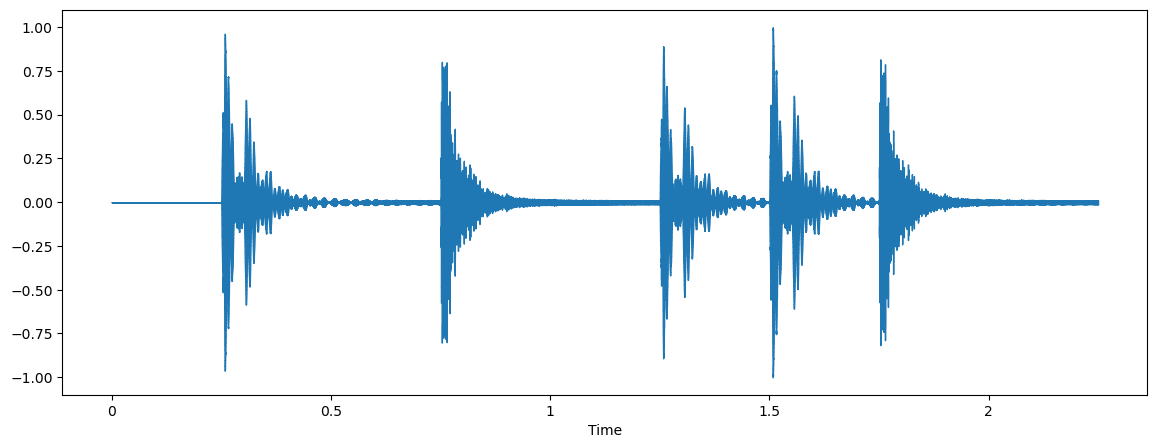

In [4]:
plt.figure(figsize=(14, 5))
librosa.display.waveshow(x, sr=sr)

### Step 3: Zoom in to visually inspect zero-crossings (ZC)

librosa.load() default: resamples audio to 22050 Hz (1 cycle per second)

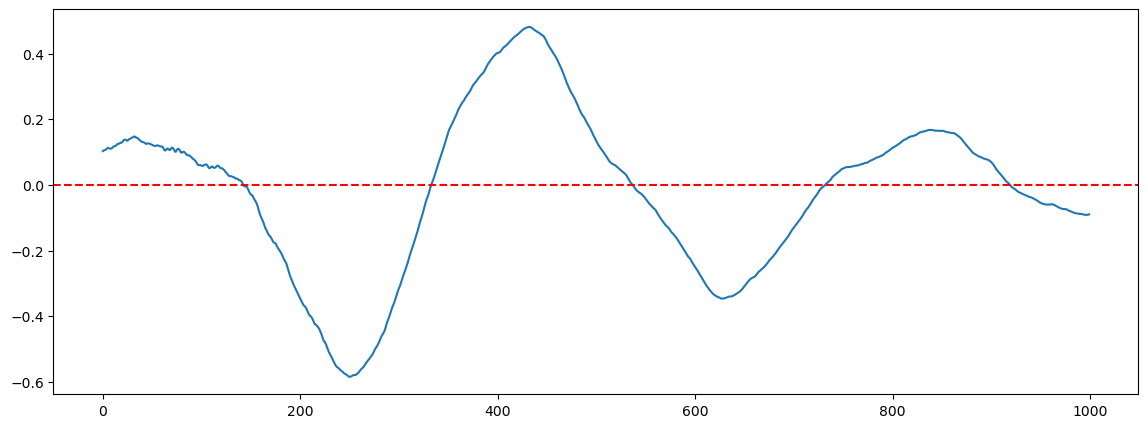

In [5]:
n0 = 6500 # (6500 / 22050) ≈ 0.295 seconds
n1 = 7500 #(7500 / 22050) ≈ 0.340 seconds 
          # covers 1000 samples covering 45 millisecond segment of the signal
plt.figure(figsize=(14, 5))
plt.plot(x[n0:n1])
plt.axhline(0, color='red', linestyle='--')

Result: 5 zero crossings.

### Step 4: Compute zero crossings

Create an array made up of `True` (ZC present) and `False` (ZC not present) values on the interval:

In [6]:
zero_crossings = librosa.zero_crossings(x[n0:n1], pad=False)

In [7]:
zero_crossings.shape

(1000,)

In [8]:
print(f"Total number of zero crossings: {sum(zero_crossings)}")

Total number of zero crossings: 5


### Step 5: Find the *zero-crossing rate* over time

In [9]:
zcrs = librosa.feature.zero_crossing_rate(x)
print(zcrs.shape)

(1, 97)


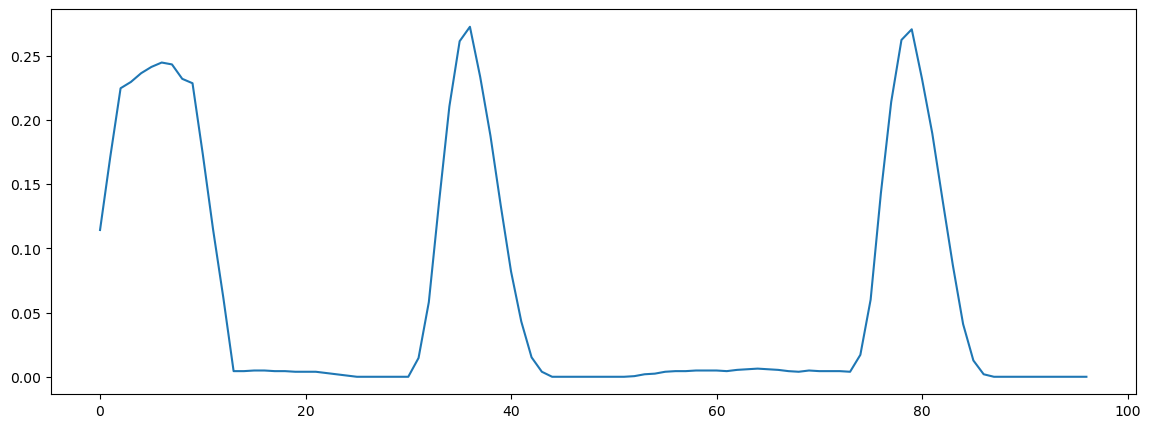

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(zcrs[0])

- Peaks indicate sections of high ZCR/high-frequency signals
- typical for signals including percussive sounds, such as a snare drums

### Step 6: Correct for False Oscillations in Silence Affecting Zero-Crossing Rate

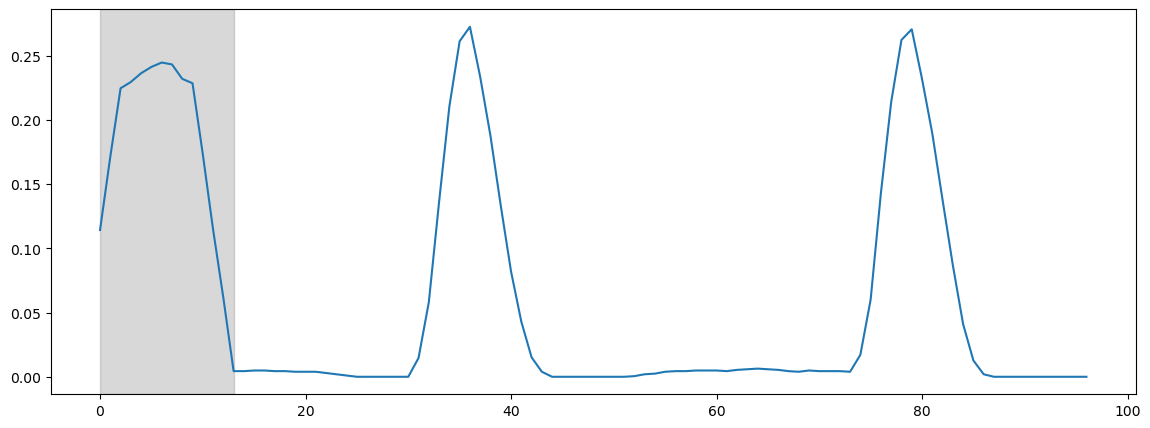

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(zcrs[0])
plt.axvspan(0, 13, color='gray', alpha=0.3) 

Problem: High ZCR in silence at the beginning

- even in silence, waveform fluctuates around zero
- ZCR gets higher, even though there is no clear sound

(-0.0001, 0.0001)

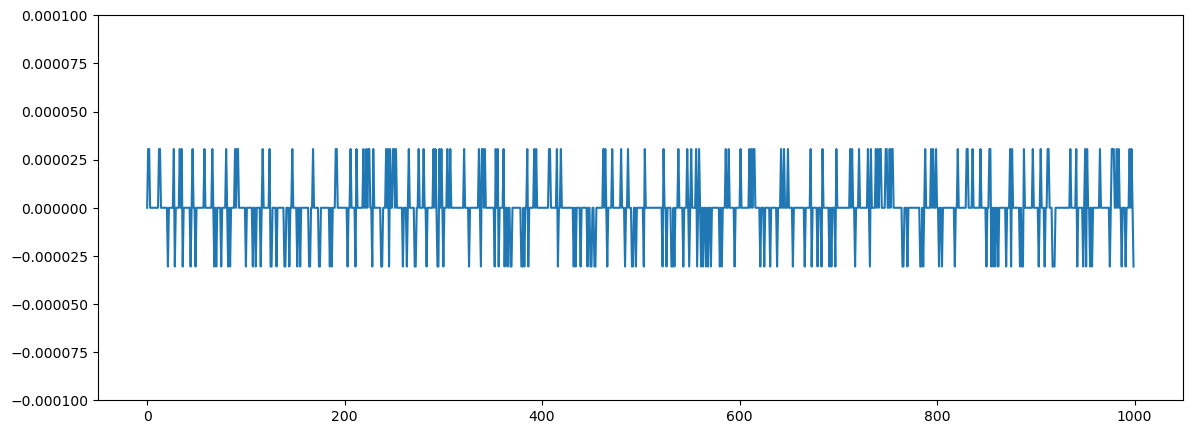

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(x[:1000])
plt.ylim(-0.0001, 0.0001)

#### Solution: Add small constant before computing ZCR

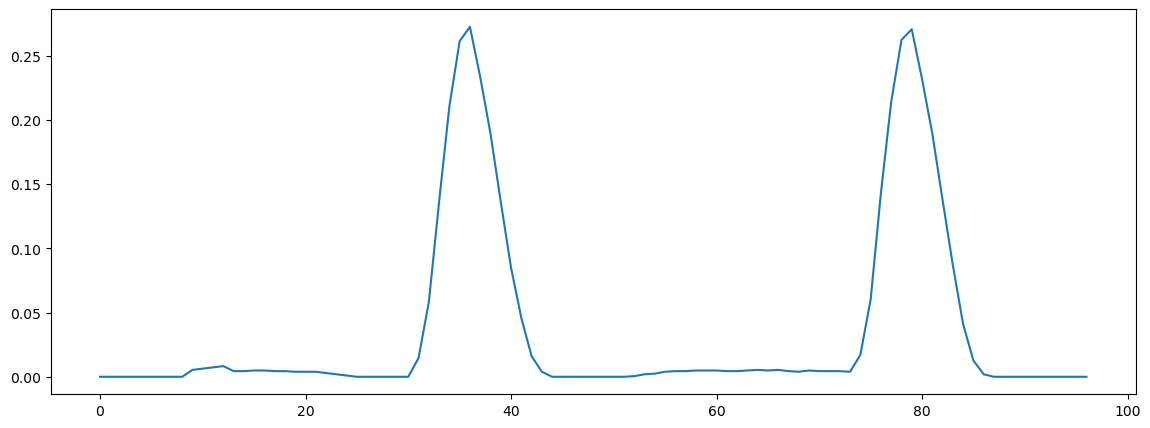

In [13]:
zcrs = librosa.feature.zero_crossing_rate(x + 0.0001)
plt.figure(figsize=(14, 5))
plt.plot(zcrs[0])

## Example #2: ZCR of an Oboe

In [14]:
ob, sr = librosa.load('audio/oboe_c6.wav')

In [15]:
ipd.Audio(ob, rate=sr)

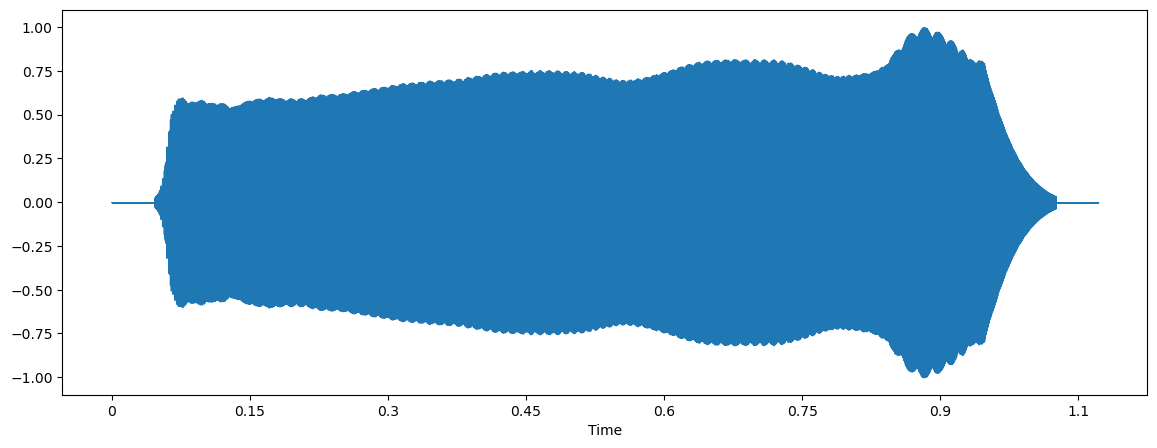

In [16]:
plt.figure(figsize=(14, 5))
librosa.display.waveshow(ob, sr=sr)

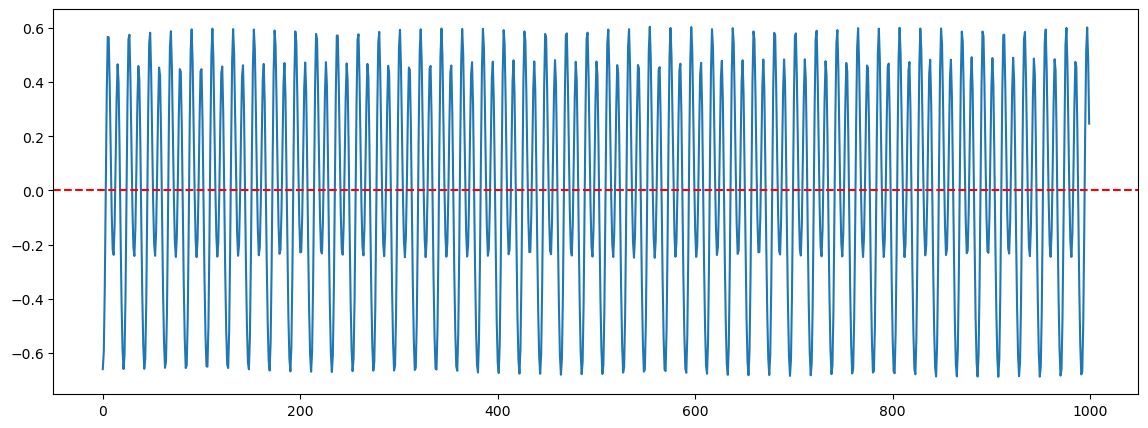

In [17]:
n0 = 6500 
n1 = 7500 

plt.figure(figsize=(14, 5))
plt.plot(ob[n0:n1])
plt.axhline(0, color='red', linestyle='--')

In [18]:
zero_crossings_ob = librosa.zero_crossings(ob[n0:n1], pad=False)

In [19]:
print(f"Total number of zero crossings: {sum(zero_crossings_ob)}")

Total number of zero crossings: 189


Oboe produces a rich, reedy, high-pitched sound
  → high-frequency content
  → rapid changes in signal’s amplitude
  → frequent zero crossings (ZC)

In [20]:
zcrob = librosa.feature.zero_crossing_rate(ob)

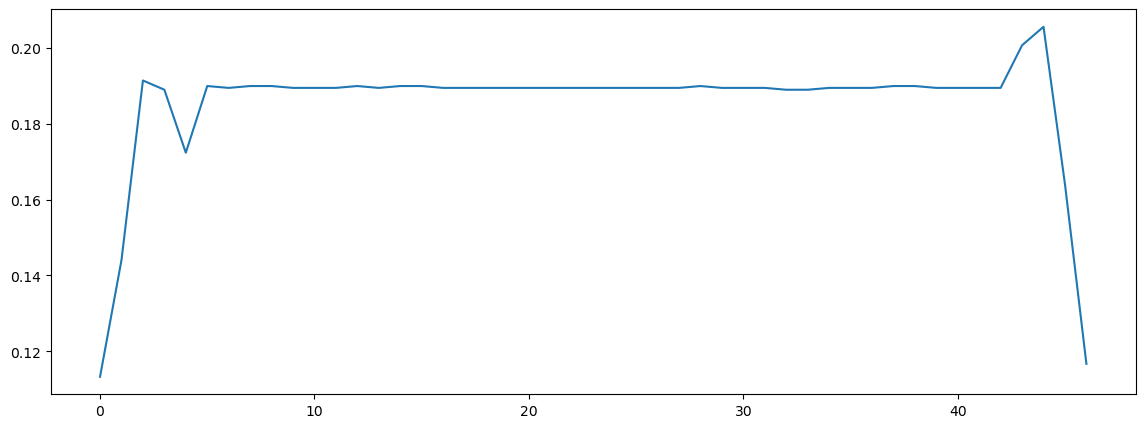

In [21]:
plt.figure(figsize=(14, 5))
plt.plot(zcrob[0])

- ZCR maintains a relatively consistent value
- steady, sustained tone with minimal variation